In [3]:
!pip install yfinance vaderSentiment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import ttest_ind

plt.style.use('seaborn-v0_8')


In [5]:
sp500 = yf.download("^GSPC", start="2017-01-20", end="2021-01-20")
sp500['Return'] = sp500['Close'].pct_change()
sp500.to_csv("sp500.csv")
sp500.head()


/tmp/ipython-input-3702245399.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2017-01-20", end="2021-01-20")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Return
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,
2017-01-20,2271.310059,2276.959961,2265.010010,2269.959961,3536850000,NaN
2017-01-23,2265.199951,2271.780029,2257.020020,2267.780029,3155240000,-0.002690
2017-01-24,2280.070068,2284.629883,2266.679932,2267.879883,3816950000,0.006565
2017-01-25,2298.370117,2299.550049,2288.879883,2288.879883,3849340000,0.008026
2017-01-26,2296.679932,2300.989990,2294.080078,2298.629883,3611510000,-0.000735


In [6]:
import os

os.listdir('/content')



['.config', 'sp500.csv', 'sample_data']

In [12]:
tweets = pd.read_csv('/content/realDonaldTrump_in_office.csv',
                     engine='python',
                     on_bad_lines='skip')
tweets.head()


,ID,Time,Tweet URL,Tweet Text
0,@realDonaldTrump,2017-01-20 06:31,https://twitter.com/realDonaldTrump/status/82...,"""It all begins today! I will see you at 11:00..."
1,@realDonaldTrump,2017-01-20 11:54,https://twitter.com/realDonaldTrump/status/82...,"""We will bring back our jobs. We will bring b..."
2,@realDonaldTrump,2017-01-20 11:55,https://twitter.com/realDonaldTrump/status/82...,"""We will follow two simple rules: BUY AMERICA..."
3,@realDonaldTrump,2017-01-20 11:58,https://twitter.com/realDonaldTrump/status/82...,"""It is time to remember that...https://www.fa..."
4,@realDonaldTrump,2017-01-20 12:13,https://twitter.com/realDonaldTrump/status/82...,"""TO ALL AMERICANS https://www.facebook.com/Do..."


In [13]:
tweets.columns


Index(['ID', ' Time', ' Tweet URL', ' Tweet Text'], dtype='object')

In [14]:
tweets.head()


,ID,Time,Tweet URL,Tweet Text
0,@realDonaldTrump,2017-01-20 06:31,https://twitter.com/realDonaldTrump/status/82...,"""It all begins today! I will see you at 11:00..."
1,@realDonaldTrump,2017-01-20 11:54,https://twitter.com/realDonaldTrump/status/82...,"""We will bring back our jobs. We will bring b..."
2,@realDonaldTrump,2017-01-20 11:55,https://twitter.com/realDonaldTrump/status/82...,"""We will follow two simple rules: BUY AMERICA..."
3,@realDonaldTrump,2017-01-20 11:58,https://twitter.com/realDonaldTrump/status/82...,"""It is time to remember that...https://www.fa..."
4,@realDonaldTrump,2017-01-20 12:13,https://twitter.com/realDonaldTrump/status/82...,"""TO ALL AMERICANS https://www.facebook.com/Do..."


In [15]:
tweets = tweets.rename(columns=lambda x: x.strip())
tweets.columns


Index(['ID', 'Time', 'Tweet URL', 'Tweet Text'], dtype='object')

In [16]:
tweets['Time'] = pd.to_datetime(tweets['Time'], errors='coerce')
tweets = tweets.dropna(subset=['Time'])  # drop rows with invalid dates
tweets.head()

mask = (tweets['Time'] >= '2017-01-20') & (tweets['Time'] < '2021-01-20')
tweets_2017_2021 = tweets[mask]
tweets_2017_2021.shape

tariff_tweets = tweets_2017_2021[
    tweets_2017_2021['Tweet Text'].str.contains('tariff', case=False, na=False)
]
tariff_tweets.head()

tariff_tweets['Date'] = tariff_tweets['Time'].dt.date
daily_counts = tariff_tweets.groupby('Date').size().rename('tweet_count')
daily_counts.head()


/tmp/ipython-input-352233480.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tariff_tweets['Date'] = tariff_tweets['Time'].dt.date


,tweet_count
Date,
2017-02-03,1
2018-03-12,1
2018-06-10,1
2018-06-26,1
2018-07-10,1


In [27]:
# Start from tariff_tweets that already only contains tariff tweets
tariff_tweets = tariff_tweets.copy()
tariff_tweets['Date'] = pd.to_datetime(tariff_tweets['Time']).dt.normalize()

daily_counts = (
    tariff_tweets
    .groupby('Date')
    .size()
    .rename('tweet_count')  # this makes it a Series with name 'tweet_count'
)

daily_counts.head()


,tweet_count
Date,
2017-02-03,1
2018-03-12,1
2018-06-10,1
2018-06-26,1
2018-07-10,1


In [28]:
sp500 = sp500.copy()
sp500.index = pd.to_datetime(sp500.index).normalize()


In [29]:
df = sp500.copy()

# Make a Date column from index
df['Date'] = df.index

# Map tweet counts by date
df['tweet_count'] = df['Date'].map(daily_counts)

# Replace NaN (no tariff tweet that day) with 0
df['tweet_count'] = df['tweet_count'].fillna(0)

df.head()


Price,Close,High,Low,Open,Volume,Return,Date,tweet_count
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,,,
Date,,,,,,,,
2017-01-20,2271.310059,2276.959961,2265.010010,2269.959961,3536850000,NaN,2017-01-20,0.0
2017-01-23,2265.199951,2271.780029,2257.020020,2267.780029,3155240000,-0.002690,2017-01-23,0.0
2017-01-24,2280.070068,2284.629883,2266.679932,2267.879883,3816950000,0.006565,2017-01-24,0.0
2017-01-25,2298.370117,2299.550049,2288.879883,2288.879883,3849340000,0.008026,2017-01-25,0.0
2017-01-26,2296.679932,2300.989990,2294.080078,2298.629883,3611510000,-0.000735,2017-01-26,0.0


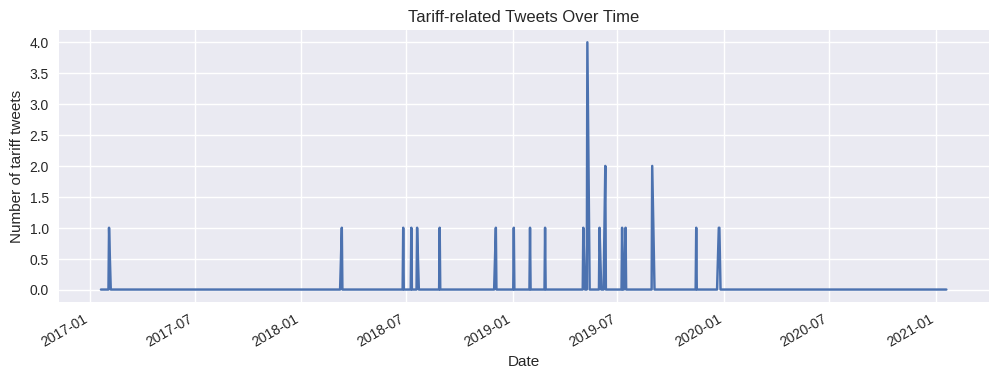

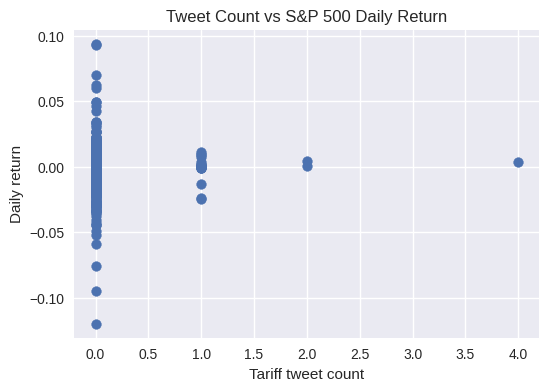

In [30]:
import matplotlib.pyplot as plt

# 1. Tariff tweet activity over time
df['tweet_count'].plot(figsize=(12,4), title="Tariff-related Tweets Over Time")
plt.xlabel("Date")
plt.ylabel("Number of tariff tweets")
plt.show()

# 2. Scatter: tweet count vs daily return
plt.figure(figsize=(6,4))
plt.scatter(df['tweet_count'], df['Return'])
plt.title("Tweet Count vs S&P 500 Daily Return")
plt.xlabel("Tariff tweet count")
plt.ylabel("Daily return")
plt.show()


In [31]:
from scipy.stats import ttest_ind

tweet_days = df[df['tweet_count'] > 0]['Return'].dropna()
non_tweet_days = df[df['tweet_count'] == 0]['Return'].dropna()

t_stat, p_val = ttest_ind(tweet_days, non_tweet_days, equal_var=False)

print("Number of tweet days:", len(tweet_days))
print("Number of non-tweet days:", len(non_tweet_days))
print("t-statistic:", t_stat)
print("p-value:", p_val)


Number of tweet days: 21
Number of non-tweet days: 984
t-statistic: -0.5418355196695531
p-value: 0.5934595310764519
